In [1]:
# ============================================================
# BRISTOL HOUSE PRICE PROJECT — POSTCODE SECTOR VERSION (2015–2024)
# End-to-end pipeline (Colab-ready)
# Uses:
#   /content/bristol_master_transactions.csv
#   /content/bs.csv
#   /content/Merged_Sapelsoa.csv
#   /content/ONSPD.csv
# Outputs:
#   /content/Bristol_PostcodeSector_2015_2024.csv
# ============================================================

# =========================
# 1) Imports + helper functions
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

def clean_postcode_unit(pc):
    """Standard UK postcode unit: uppercase + single space before last 3 chars."""
    if pd.isna(pc):
        return np.nan
    pc = str(pc).strip().upper().replace(" ", "")
    if len(pc) < 5:
        return np.nan
    return pc[:-3] + " " + pc[-3:]

def postcode_sector_from_unit(pc_unit):
    """
    Convert unit postcode -> sector postcode.
    Example:
      BS1 1AA -> BS1 1
      BS10 5AA -> BS10 5
    """
    pc_unit = clean_postcode_unit(pc_unit)
    if pd.isna(pc_unit):
        return np.nan
    try:
        outward, inward = pc_unit.split(" ")
        return outward + " " + inward[0]
    except Exception:
        return np.nan

def standardise_lad_cols(df):
    """Make LAD 2021 vs LAD 2023 consistent + standardise LSOA col names."""
    rename_map = {}
    if "LAD 2021 Code" in df.columns: rename_map["LAD 2021 Code"] = "LAD_Code"
    if "LAD 2021 Name" in df.columns: rename_map["LAD 2021 Name"] = "LAD_Name"
    if "LAD 2023 Code" in df.columns: rename_map["LAD 2023 Code"] = "LAD_Code"
    if "LAD 2023 Name" in df.columns: rename_map["LAD 2023 Name"] = "LAD_Name"
    if "LSOA 2021 Code" in df.columns: rename_map["LSOA 2021 Code"] = "LSOA_2021_Code"
    if "LSOA 2021 Name" in df.columns: rename_map["LSOA 2021 Name"] = "LSOA_2021_Name"
    df = df.rename(columns=rename_map)
    for col in ["LAD_Code", "LAD_Name", "LSOA_2021_Code", "LSOA_2021_Name"]:
        if col not in df.columns:
            df[col] = pd.NA
    return df

def add_total_sex_age_cols(ons):
    """
    Merge Female (F0..F90) and Male (M0..M90) into Total (T0..T90)
    + totals Female_Total, Male_Total, Pop_Total_FM.
    (We will NOT use T* in final merge; totals only.)
    """
    f_cols = [c for c in ons.columns if re.fullmatch(r"F\d+", str(c))]
    m_cols = [c for c in ons.columns if re.fullmatch(r"M\d+", str(c))]
    f_ages = sorted([int(c[1:]) for c in f_cols])
    m_ages = sorted([int(c[1:]) for c in m_cols])
    common_ages = sorted(set(f_ages).intersection(set(m_ages)))

    if common_ages:
        ons["Female_Total"] = ons[[f"F{a}" for a in common_ages]].apply(pd.to_numeric, errors="coerce").sum(axis=1)
        ons["Male_Total"]   = ons[[f"M{a}" for a in common_ages]].apply(pd.to_numeric, errors="coerce").sum(axis=1)
        ons["Pop_Total_FM"] = ons["Female_Total"] + ons["Male_Total"]
    else:
        ons["Female_Total"] = pd.NA
        ons["Male_Total"] = pd.NA
        ons["Pop_Total_FM"] = pd.NA

    return ons

def find_col(cols, candidates):
    """Find a column in cols matching one of candidates (case-insensitive)."""
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

In [2]:
# =========================
# 2) Load datasets
# =========================
transactions_path = "/content/bristol_master_transactions.csv"
codepoint_path    = "/content/bs.csv"
ons_path          = "/content/Merged_Sapelsoa.csv"
onspd_path        = "/content/ONSPD.csv"

for p in [transactions_path, codepoint_path, ons_path, onspd_path]:
    if not Path(p).exists():
        raise FileNotFoundError(f"Missing file at: {p}")

tx = pd.read_csv(transactions_path)

# bs.csv typically has NO header row; assign names
bs_cols = [
    "postcode_unit", "pqi", "easting", "northing",
    "country_code", "nhs_regional_ha", "nhs_ha",
    "admin_county", "admin_district", "admin_ward"
]
bs = pd.read_csv(codepoint_path, header=None, names=bs_cols)

ons = pd.read_csv(ons_path)

print("Transactions:", tx.shape)
print("Code-Point:", bs.shape)
print("ONS:", ons.shape)


Transactions: (127755, 16)
Code-Point: (27393, 10)
ONS: (2948, 189)


In [3]:
# =========================
# 3) Clean / prepare transactions (POSTCODE SECTOR + year)
# =========================
tx["postcode_unit"] = tx["postcode"].apply(clean_postcode_unit)
tx["postcode_sector"] = tx["postcode_unit"].apply(postcode_sector_from_unit)

tx["date_of_transfer"] = pd.to_datetime(tx["date_of_transfer"], errors="coerce")
tx["year"] = tx["date_of_transfer"].dt.year

tx = tx.dropna(subset=["postcode_sector", "price", "year"])
tx = tx[(tx["price"] > 0) & (tx["year"].between(2015, 2024))]

# Keep Bristol sectors only (BS*)
tx = tx[tx["postcode_sector"].astype(str).str.startswith("BS")].copy()

print("Transactions after cleaning (sector):", tx.shape)
print(tx[["postcode_sector","year","price"]].head())

Transactions after cleaning (sector): (122484, 19)
  postcode_sector  year   price
0           BS1 6  2015  257500
1          BS10 5  2015  427500
2           BS4 1  2015  140000
3          BS10 5  2015  280000
4           BS3 3  2015  185000


In [4]:
# =========================
# 4) Clean / prepare Code-Point (UNIT -> SECTOR centroid)
# =========================
bs["postcode_unit"] = bs["postcode_unit"].apply(clean_postcode_unit)
bs["postcode_sector"] = bs["postcode_unit"].apply(postcode_sector_from_unit)

# Numeric conversion safety
bs["easting"] = pd.to_numeric(bs["easting"], errors="coerce")
bs["northing"] = pd.to_numeric(bs["northing"], errors="coerce")

bs_geo = (
    bs.dropna(subset=["postcode_sector", "easting", "northing"])
      .groupby("postcode_sector", as_index=False)
      .agg(easting=("easting", "mean"),
           northing=("northing", "mean"))
)

# Keep Bristol sectors
bs_geo = bs_geo[bs_geo["postcode_sector"].astype(str).str.startswith("BS")].copy()

print("Code-Point sector geography:", bs_geo.shape)
print(bs_geo.head())

Code-Point sector geography: (166, 3)
  postcode_sector        easting       northing
0           BS1 1  358827.841270  172961.984127
1           BS1 2  358846.676471  173215.882353
2           BS1 3  359164.529412  173519.899160
3           BS1 4  358711.183673  172685.346939
4           BS1 5  358269.202614  172825.013072


In [5]:
# =========================
# 5) Prepare ONS SAPELSOA (totals only)
# =========================
ons = standardise_lad_cols(ons)
ons = add_total_sex_age_cols(ons)

# Ensure Year numeric
if "Year" in ons.columns:
    ons["Year"] = pd.to_numeric(ons["Year"], errors="coerce")
elif "year" in ons.columns:
    ons["Year"] = pd.to_numeric(ons["year"], errors="coerce")
else:
    raise ValueError("ONS file must have a Year column (Year or year).")

print("ONS after totals:", ons.shape)
print(ons[["LSOA_2021_Code","Year","Female_Total","Male_Total","Pop_Total_FM"]].head())

ONS after totals: (2948, 192)
  LSOA_2021_Code  Year  Female_Total  Male_Total  Pop_Total_FM
0      E01014485  2015           994         911          1905
1      E01014486  2015          1261        1303          2564
2      E01014487  2015           976        1020          1996
3      E01014488  2015           998        1017          2015
4      E01014489  2015          1240        1364          2604


In [6]:
# =========================
# 6) Build target variable: average price by POSTCODE SECTOR and year
# =========================
price_by_sector_year = (
    tx.groupby(["postcode_sector", "year"], as_index=False)
      .agg(avg_price=("price", "mean"),
           median_price=("price", "median"),
           n_sales=("price", "size"))
)

print("Price table (sector×year):", price_by_sector_year.shape)
print(price_by_sector_year.head())

Price table (sector×year): (1144, 5)
  postcode_sector  year     avg_price  median_price  n_sales
0           BS1 1  2015  3.288500e+05      128000.0       27
1           BS1 1  2016  4.569979e+05      132750.0       24
2           BS1 1  2017  4.977970e+05      168550.0       13
3           BS1 1  2018  3.299123e+05      187000.0       81
4           BS1 1  2019  1.652299e+06      207500.0       28


In [7]:
# =========================
# 7) Add geography (sector centroid)
# =========================
price_geo = price_by_sector_year.merge(bs_geo, on="postcode_sector", how="left")
print("After adding geography:", price_geo.shape)
print(price_geo.head())


# =========================
# 8) ONSPD lookup: UNIT -> LSOA, then reduce to SECTOR -> dominant LSOA
# =========================
# Robust read
try:
    lookup_raw = pd.read_csv(onspd_path)
except Exception as e:
    print("Standard read_csv failed:", repr(e))
    print("Trying tolerant read (engine='python', on_bad_lines='skip')...")
    lookup_raw = pd.read_csv(onspd_path, engine="python", on_bad_lines="skip", encoding_errors="replace")

postcode_col = find_col(lookup_raw.columns, ["pcds", "pcd", "postcode", "PCDS", "PCD"])
lsoa_col = find_col(lookup_raw.columns, ["lsoa21", "lsoa21cd", "LSOA21CD", "lsoa_2021"])
if lsoa_col is None:
    lsoa_col = find_col(lookup_raw.columns, ["lsoa11", "lsoa11cd", "LSOA11CD", "lsoa_2011"])

if postcode_col is None or lsoa_col is None:
    raise ValueError(
        f"Could not identify postcode + LSOA columns.\n"
        f"postcode_col={postcode_col}, lsoa_col={lsoa_col}\n"
        f"Columns (first 60): {lookup_raw.columns.tolist()[:60]}"
    )

lookup = lookup_raw[[postcode_col, lsoa_col]].copy()
lookup["postcode_unit"] = lookup[postcode_col].apply(clean_postcode_unit)
lookup["postcode_sector"] = lookup["postcode_unit"].apply(postcode_sector_from_unit)
lookup["LSOA_2021_Code"] = lookup[lsoa_col].astype(str)

lookup = lookup.dropna(subset=["postcode_sector","LSOA_2021_Code"])
lookup = lookup[["postcode_sector","LSOA_2021_Code"]].drop_duplicates()

# Bristol sectors only
lookup = lookup[lookup["postcode_sector"].astype(str).str.startswith("BS")].copy()

# Reduce many-to-one: sector -> dominant LSOA (mode)
lookup_sector = (
    lookup.groupby("postcode_sector")["LSOA_2021_Code"]
          .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
          .reset_index()
)

print("Lookup sector shape:", lookup_sector.shape)
print(lookup_sector.head())

After adding geography: (1144, 7)
  postcode_sector  year     avg_price  median_price  n_sales       easting  \
0           BS1 1  2015  3.288500e+05      128000.0       27  358827.84127   
1           BS1 1  2016  4.569979e+05      132750.0       24  358827.84127   
2           BS1 1  2017  4.977970e+05      168550.0       13  358827.84127   
3           BS1 1  2018  3.299123e+05      187000.0       81  358827.84127   
4           BS1 1  2019  1.652299e+06      207500.0       28  358827.84127   

        northing  
0  172961.984127  
1  172961.984127  
2  172961.984127  
3  172961.984127  
4  172961.984127  


/tmp/ipython-input-751529031.py:14: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  lookup_raw = pd.read_csv(onspd_path)


Lookup sector shape: (206, 2)
  postcode_sector LSOA_2021_Code
0           BS0 1      E01035215
1           BS1 1      E01014654
2           BS1 2      E01033342
3           BS1 3      E01014489
4           BS1 4      E01033353


In [8]:
# =========================
# 9) Merge: price_geo (sector×year) + lookup_sector (sector -> LSOA)
# =========================
price_geo_lsoa = price_geo.merge(lookup_sector, on="postcode_sector", how="left")
print("After adding LSOA:", price_geo_lsoa.shape)
print(price_geo_lsoa.head())

After adding LSOA: (1144, 8)
  postcode_sector  year     avg_price  median_price  n_sales       easting  \
0           BS1 1  2015  3.288500e+05      128000.0       27  358827.84127   
1           BS1 1  2016  4.569979e+05      132750.0       24  358827.84127   
2           BS1 1  2017  4.977970e+05      168550.0       13  358827.84127   
3           BS1 1  2018  3.299123e+05      187000.0       81  358827.84127   
4           BS1 1  2019  1.652299e+06      207500.0       28  358827.84127   

        northing LSOA_2021_Code  
0  172961.984127      E01014654  
1  172961.984127      E01014654  
2  172961.984127      E01014654  
3  172961.984127      E01014654  
4  172961.984127      E01014654  


In [9]:
# =========================
# 10) Merge ONS totals (LSOA×Year -> sector×year)
# =========================
ons_features = ["LSOA_2021_Code", "Year", "Female_Total", "Male_Total", "Pop_Total_FM"]
ons_features = [c for c in ons_features if c in ons.columns]
ons_small = ons[ons_features].copy()

final_df = price_geo_lsoa.merge(
    ons_small,
    left_on=["LSOA_2021_Code", "year"],
    right_on=["LSOA_2021_Code", "Year"],
    how="left"
).drop(columns=["Year"], errors="ignore")

print("FINAL merged table:", final_df.shape)
print(final_df.columns.tolist())
print(final_df.head())

FINAL merged table: (1205, 11)
['postcode_sector', 'year', 'avg_price', 'median_price', 'n_sales', 'easting', 'northing', 'LSOA_2021_Code', 'Female_Total', 'Male_Total', 'Pop_Total_FM']
  postcode_sector  year     avg_price  median_price  n_sales       easting  \
0           BS1 1  2015  3.288500e+05      128000.0       27  358827.84127   
1           BS1 1  2016  4.569979e+05      132750.0       24  358827.84127   
2           BS1 1  2017  4.977970e+05      168550.0       13  358827.84127   
3           BS1 1  2018  3.299123e+05      187000.0       81  358827.84127   
4           BS1 1  2019  1.652299e+06      207500.0       28  358827.84127   

        northing LSOA_2021_Code  Female_Total  Male_Total  Pop_Total_FM  
0  172961.984127      E01014654        1263.0      1335.0        2598.0  
1  172961.984127      E01014654        1265.0      1314.0        2579.0  
2  172961.984127      E01014654        1245.0      1283.0        2528.0  
3  172961.984127      E01014654        1233.0    

In [10]:
# =========================
# 11) Save final dataset (POSTCODE SECTOR)
# =========================
final_out = "/content/Bristol_PostcodeSector_2015_2024.csv"
final_df.to_csv(final_out, index=False, encoding="utf-8")
print("Saved:", final_out)

Saved: /content/Bristol_PostcodeSector_2015_2024.csv


In [11]:
# ============================================================
# 1) EDA (Exploratory Data Analysis) — POSTCODE SECTOR VERSION
# Assumes final_df has: postcode_sector (NOT postcode_unit)
# ============================================================

# 1.1 Basic info
print("\n--- INFO ---")
final_df.info()

# 1.2 Missing values table
print("\n--- MISSING VALUES (%) ---")
missing_pct = (final_df.isna().mean()*100).sort_values(ascending=False)
print(missing_pct)

# 1.3 Summary stats
eda_num_cols = ["avg_price","median_price","n_sales","easting","northing","Female_Total","Male_Total","Pop_Total_FM"]
print("\n--- SUMMARY STATS ---")
print(final_df[eda_num_cols].describe())

# 1.4 Unique counts (SECTORS)
print("\n--- UNIQUE COUNTS ---")
print("Unique postcode sectors:", final_df["postcode_sector"].nunique())
print("Unique years:", final_df["year"].nunique())
print("Years:", sorted(final_df["year"].dropna().unique()))


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   postcode_sector  1205 non-null   object 
 1   year             1205 non-null   int32  
 2   avg_price        1205 non-null   float64
 3   median_price     1205 non-null   float64
 4   n_sales          1205 non-null   int64  
 5   easting          1201 non-null   float64
 6   northing         1201 non-null   float64
 7   LSOA_2021_Code   1204 non-null   object 
 8   Female_Total     678 non-null    float64
 9   Male_Total       678 non-null    float64
 10  Pop_Total_FM     678 non-null    float64
dtypes: float64(7), int32(1), int64(1), object(2)
memory usage: 99.0+ KB

--- MISSING VALUES (%) ---
Female_Total       43.734440
Pop_Total_FM       43.734440
Male_Total         43.734440
easting             0.331950
northing            0.331950
LSOA_2021_Code      0.082988
postco

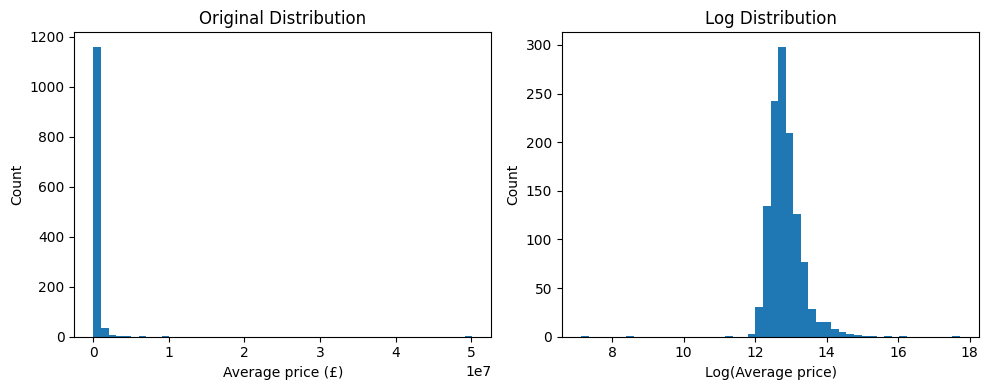

In [12]:
# 1.5 Distribution of avg_price (Original + Log)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
final_df["avg_price"].dropna().plot(kind="hist", bins=50)
plt.xlabel("Average price (£)")
plt.ylabel("Count")
plt.title("Original Distribution")

plt.subplot(1,2,2)
np.log(final_df["avg_price"].dropna().clip(lower=1)).plot(kind="hist", bins=50)
plt.xlabel("Log(Average price)")
plt.ylabel("Count")
plt.title("Log Distribution")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

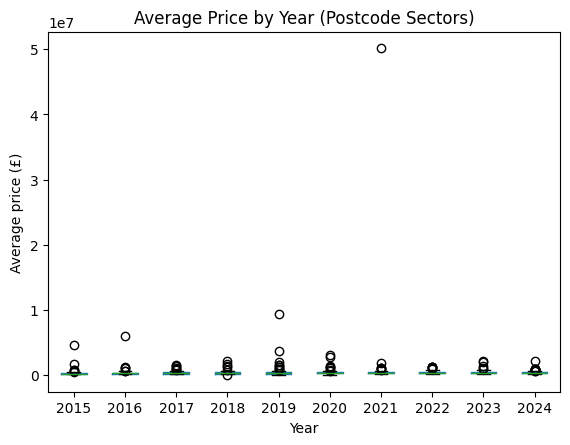

In [14]:
# 1.6 Boxplot of avg_price by year
plt.figure()
final_df.boxplot(column="avg_price", by="year", grid=False)
plt.suptitle("")
plt.title("Average Price by Year (Postcode Sectors)")
plt.xlabel("Year")
plt.ylabel("Average price (£)")
plt.show()

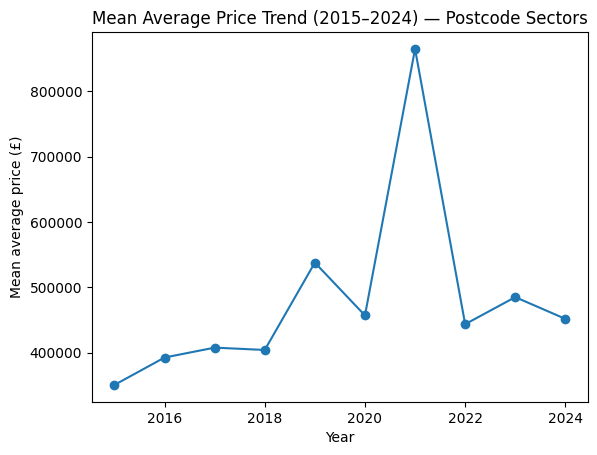

In [15]:
# 1.7 Time series of mean price
plt.figure()
final_df.groupby("year")["avg_price"].mean().plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Mean average price (£)")
plt.title("Mean Average Price Trend (2015–2024) — Postcode Sectors")
plt.show()

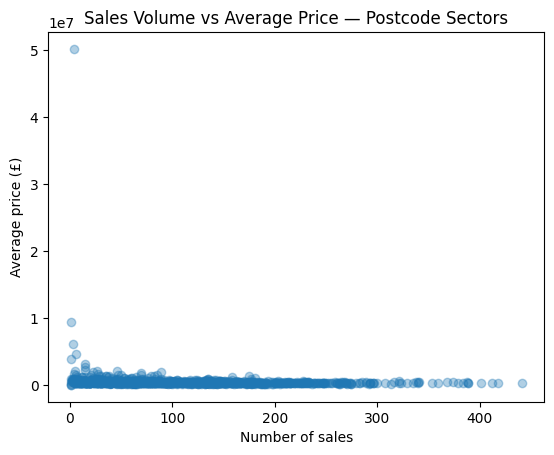

In [16]:
# 1.8 Scatter: sales vs price
plt.figure()
plt.scatter(final_df["n_sales"], final_df["avg_price"], alpha=0.35)
plt.xlabel("Number of sales")
plt.ylabel("Average price (£)")
plt.title("Sales Volume vs Average Price — Postcode Sectors")
plt.show()

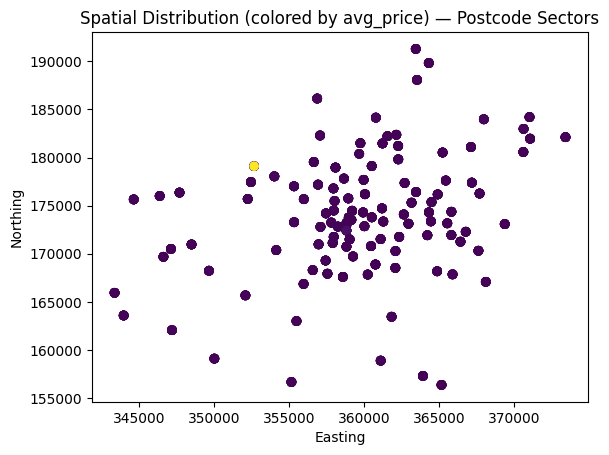

In [17]:
# 1.9 Spatial scatter (easting/northing colored by avg_price)
plt.figure()
plt.scatter(final_df["easting"], final_df["northing"], c=final_df["avg_price"])
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Spatial Distribution (colored by avg_price) — Postcode Sectors")
plt.show()

In [18]:
# 1.10 Correlations with avg_price (numeric)
num_df = final_df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)["avg_price"].sort_values(ascending=False)
print("\n--- TOP CORRELATIONS WITH avg_price ---")
print(corr.head(15))


--- TOP CORRELATIONS WITH avg_price ---
avg_price       1.000000
median_price    0.886010
Male_Total      0.050984
northing        0.036970
year            0.032937
Pop_Total_FM    0.024894
Female_Total   -0.004413
easting        -0.066158
n_sales        -0.097287
Name: avg_price, dtype: float64


In [19]:
# 1.11 Outlier check (IQR rule on avg_price)
q1 = final_df["avg_price"].quantile(0.25)
q3 = final_df["avg_price"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = final_df[(final_df["avg_price"] < lower) | (final_df["avg_price"] > upper)]
print("\nOutliers by IQR rule:", outliers.shape[0], "rows")
print(outliers[["postcode_sector","year","avg_price"]].head())

# Optional: log transform target for stability (store in dataset)
final_df["log_avg_price"] = np.log(final_df["avg_price"].clip(lower=1))
print("\nAdded log_avg_price for optional modelling.")


Outliers by IQR rule: 78 rows
   postcode_sector  year     avg_price
4            BS1 1  2019  1.652299e+06
9            BS1 1  2023  9.348571e+05
11           BS1 2  2015  4.634815e+06
12           BS1 2  2016  1.264091e+06
14           BS1 2  2018  1.403329e+06

Added log_avg_price for optional modelling.


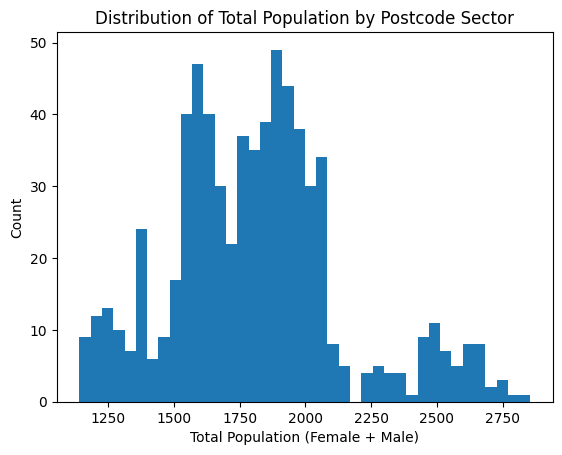

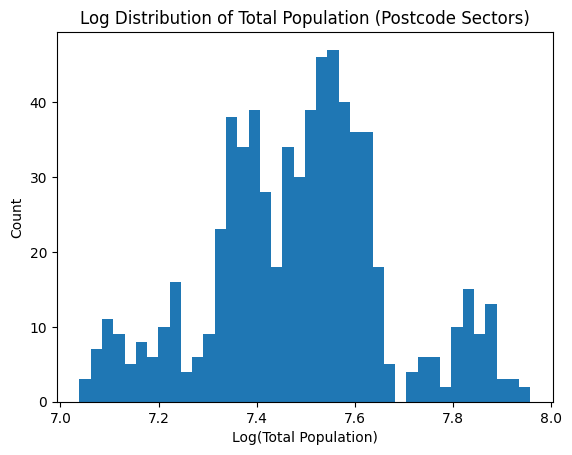

In [20]:
# =========================
# ONS EDA — POSTCODE SECTOR VERSION
# =========================

# 1.12 Total population distribution
plt.figure()
final_df["Pop_Total_FM"].dropna().plot(kind="hist", bins=40)
plt.xlabel("Total Population (Female + Male)")
plt.ylabel("Count")
plt.title("Distribution of Total Population by Postcode Sector")
plt.show()

# Log distribution of population
plt.figure()
np.log(final_df["Pop_Total_FM"].dropna().clip(lower=1)).plot(kind="hist", bins=40)
plt.xlabel("Log(Total Population)")
plt.ylabel("Count")
plt.title("Log Distribution of Total Population (Postcode Sectors)")
plt.show()

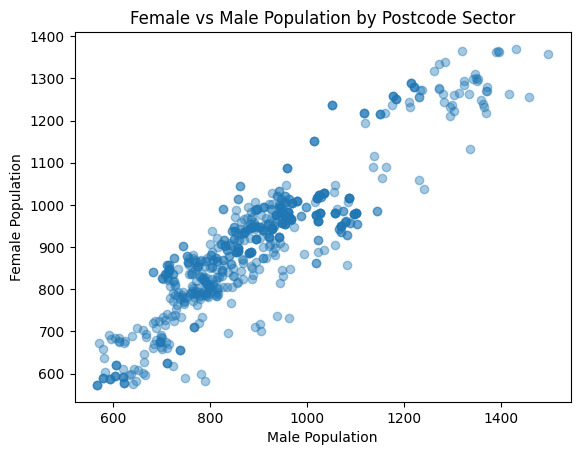

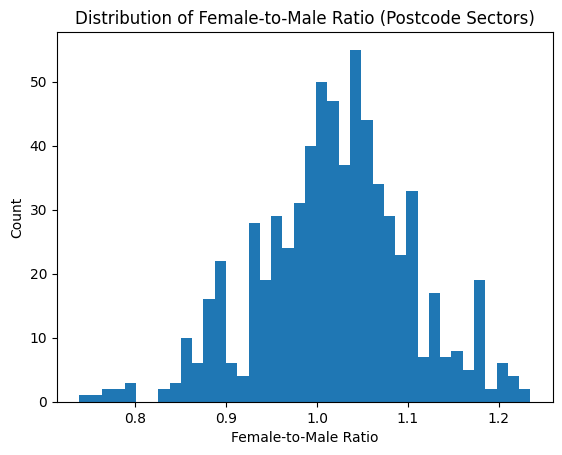

In [21]:
# 1.13 Gender composition analysis
# Female vs Male population (scatter)
plt.figure()
plt.scatter(
    final_df["Male_Total"],
    final_df["Female_Total"],
    alpha=0.4
)
plt.xlabel("Male Population")
plt.ylabel("Female Population")
plt.title("Female vs Male Population by Postcode Sector")
plt.show()

# Gender ratio distribution
final_df["female_male_ratio"] = final_df["Female_Total"] / final_df["Male_Total"]

plt.figure()
final_df["female_male_ratio"].dropna().plot(kind="hist", bins=40)
plt.xlabel("Female-to-Male Ratio")
plt.ylabel("Count")
plt.title("Distribution of Female-to-Male Ratio (Postcode Sectors)")
plt.show()

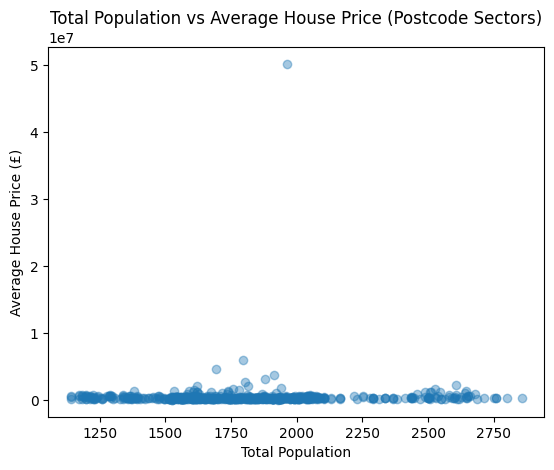

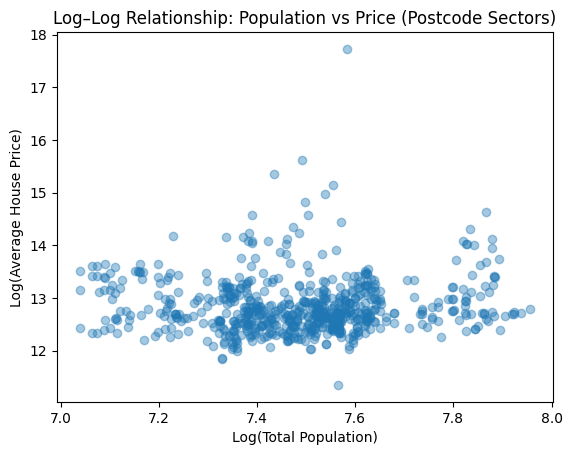

In [22]:
# 1.14 Relationship between ONS population and house prices
# Total population vs average price
plt.figure()
plt.scatter(
    final_df["Pop_Total_FM"],
    final_df["avg_price"],
    alpha=0.4
)
plt.xlabel("Total Population")
plt.ylabel("Average House Price (£)")
plt.title("Total Population vs Average House Price (Postcode Sectors)")
plt.show()

# Log–log relationship
plt.figure()
plt.scatter(
    np.log(final_df["Pop_Total_FM"].clip(lower=1)),
    np.log(final_df["avg_price"].clip(lower=1)),
    alpha=0.4
)
plt.xlabel("Log(Total Population)")
plt.ylabel("Log(Average House Price)")
plt.title("Log–Log Relationship: Population vs Price (Postcode Sectors)")
plt.show()

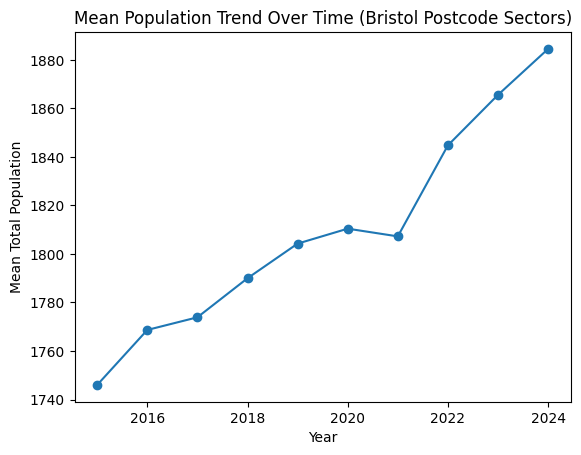

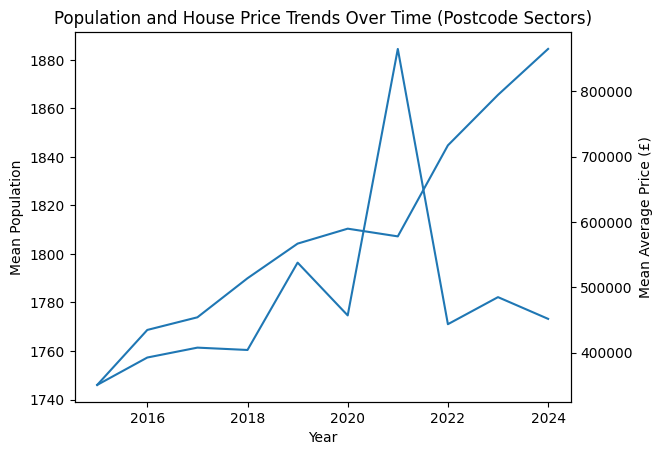

In [23]:
# 1.15 Population change over time (ONS + temporal insight)
# Mean population trend over time
pop_trend = final_df.groupby("year")["Pop_Total_FM"].mean()

plt.figure()
pop_trend.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Mean Total Population")
plt.title("Mean Population Trend Over Time (Bristol Postcode Sectors)")
plt.show()

# Population vs price trend together (dual plots)
fig, ax1 = plt.subplots()

ax1.plot(final_df.groupby("year")["Pop_Total_FM"].mean())
ax1.set_xlabel("Year")
ax1.set_ylabel("Mean Population")

ax2 = ax1.twinx()
ax2.plot(final_df.groupby("year")["avg_price"].mean())
ax2.set_ylabel("Mean Average Price (£)")

plt.title("Population and House Price Trends Over Time (Postcode Sectors)")
plt.show()

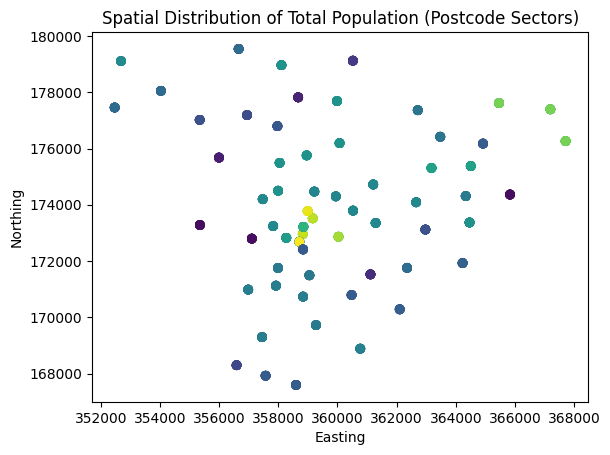

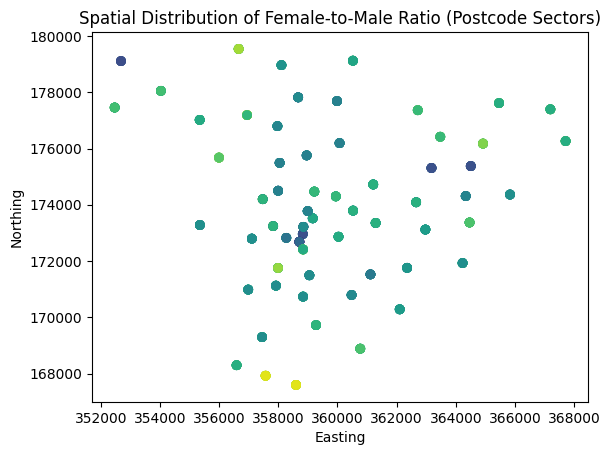

In [24]:
# 1.16 Spatial population patterns (ONS + geography)
# Spatial distribution of population
plt.figure()
plt.scatter(
    final_df["easting"],
    final_df["northing"],
    c=final_df["Pop_Total_FM"],
)
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Spatial Distribution of Total Population (Postcode Sectors)")
plt.show()

# Spatial distribution of gender ratio
plt.figure()
plt.scatter(
    final_df["easting"],
    final_df["northing"],
    c=final_df["female_male_ratio"],
)
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Spatial Distribution of Female-to-Male Ratio (Postcode Sectors)")
plt.show()

In [25]:
# ============================================================
# Imports for Modelling & Evaluation
# ============================================================

# ----------------------------
# Scikit-learn core
# ----------------------------
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ----------------------------
# Preprocessing
# ----------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----------------------------
# Metrics
# ----------------------------
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ----------------------------
# Models
# ----------------------------
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ----------------------------
# Model interpretation
# ----------------------------
from sklearn.inspection import permutation_importance


In [26]:
# ============================================================
# MODELLING — POSTCODE SECTOR VERSION
# (Only change needed: use postcode_sector when saving outputs later)
# Your features (easting/northing/n_sales + ONS totals + year) stay the same.
# ============================================================

# ----------------------------
# 1) Choose features + target
# ----------------------------
numeric_features = ["easting","northing","n_sales","Female_Total","Male_Total","Pop_Total_FM"]
categorical_features = ["year"]  # treat year as categorical (often helps)

TARGET = "avg_price"  # try "log_avg_price" if you created it earlier

X = final_df[numeric_features + categorical_features].copy()
y = final_df[TARGET].copy()

# drop missing target
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# ----------------------------
# 2) Preprocessing
# ----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [29]:
# ----------------------------
# 3) Define models (fast set)
# ----------------------------
models_fast = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=42, max_depth=6, learning_rate=0.05, max_iter=200
    ),
    "RandomForest_fast": RandomForestRegressor(
        n_estimators=150, random_state=42, n_jobs=-1,
        max_depth=20, min_samples_leaf=3
    )
}

# ----------------------------
# Evaluation metrics helper
# ----------------------------
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


# ----------------------------
# 4) Fit + evaluate (test set)
# ----------------------------
results = []
fitted_pipes = {}

for name, model in models_fast.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae, rmse, r2 = eval_metrics(y_test, pred)
    results.append([name, mae, rmse, r2])
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"]).sort_values("RMSE")
print(results_df)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.269e+15, tolerance: 2.677e+11
  model = cd_fast.enet_coordinate_descent(


                  Model            MAE           RMSE        R2
4     RandomForest_fast  126524.936178  376402.627397 -1.037085
1                 Ridge  285884.962221  385901.025835 -1.141193
2                 Lasso  288160.306961  387731.313636 -1.161552
3  HistGradientBoosting  182543.557139  389265.970138 -1.178697
0      LinearRegression  292020.019077  391853.285481 -1.207755


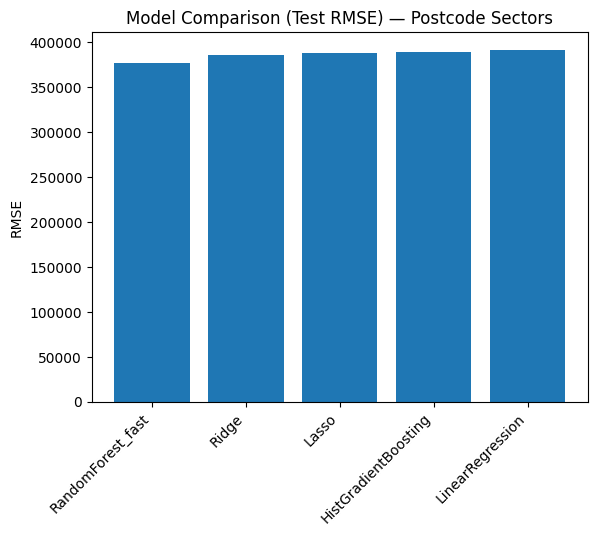

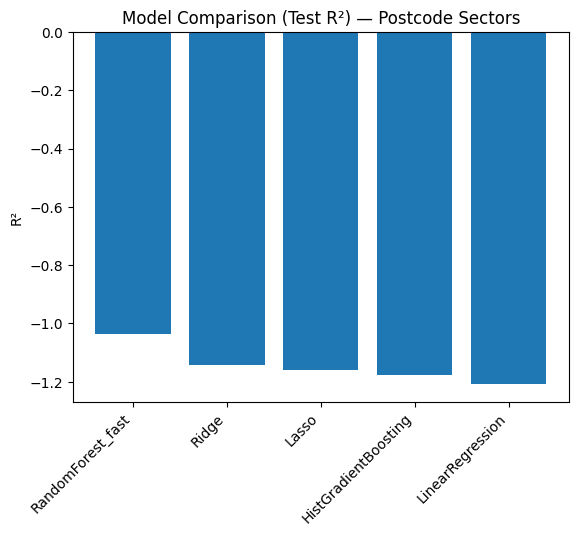

In [30]:
# ----------------------------
# 4b) Plot model comparison (RMSE + R2)
# ----------------------------
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Model Comparison (Test RMSE) — Postcode Sectors")
plt.show()

plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Model Comparison (Test R²) — Postcode Sectors")
plt.show()

In [31]:
# ----------------------------
# 4c) Select best model + predictions
# ----------------------------
best_model_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipes[best_model_name]

best_pred = best_pipe.predict(X_test)

best_mae, best_rmse, best_r2 = eval_metrics(y_test, best_pred)
print("\n=== BEST MODEL (Postcode Sectors) ===")
print("Best model:", best_model_name)
print("MAE:", best_mae)
print("RMSE:", best_rmse)
print("R²:", best_r2)


=== BEST MODEL (Postcode Sectors) ===
Best model: RandomForest_fast
MAE: 126524.93617807563
RMSE: 376402.6273968634
R²: -1.0370850483485854


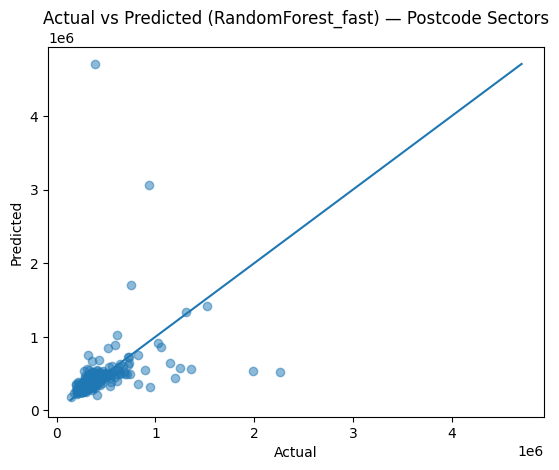

In [32]:
# ----------------------------
# 4d) Actual vs Predicted scatter plot (best model)
# ----------------------------
plt.figure()
plt.scatter(y_test, best_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted ({best_model_name}) — Postcode Sectors")
minv = min(y_test.min(), best_pred.min())
maxv = max(y_test.max(), best_pred.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()

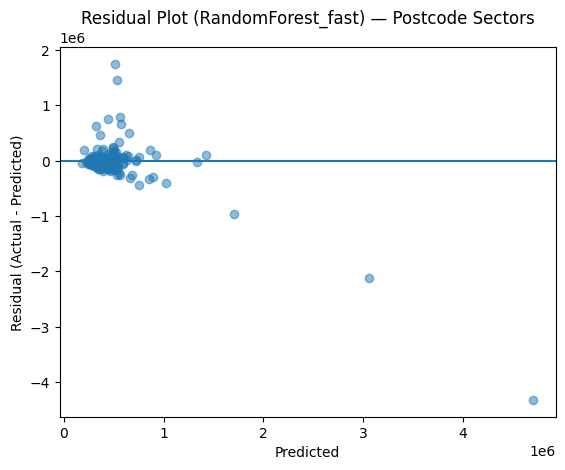

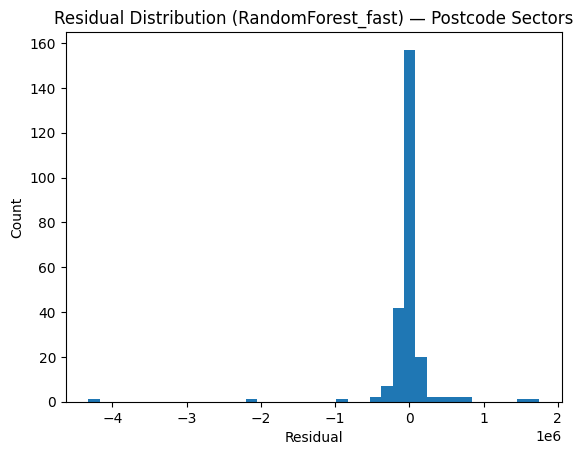

In [33]:
# ----------------------------
# 4e) Residual plot (best model)
# ----------------------------
residuals = y_test - best_pred

plt.figure()
plt.scatter(best_pred, residuals, alpha=0.5)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot ({best_model_name}) — Postcode Sectors")
plt.axhline(0)
plt.show()

plt.figure()
plt.hist(residuals, bins=40)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title(f"Residual Distribution ({best_model_name}) — Postcode Sectors")
plt.show()


=== Performance by year (best model) — Postcode Sectors ===
   year            MAE           RMSE        R2     N
0  2015   92281.392992  115693.655299  0.538707  23.0
1  2016   84566.950228  131798.939743  0.551487  24.0
2  2017   85129.422227  156489.608915  0.717770  22.0
3  2018   72880.874344  149039.749497  0.452016  23.0
4  2019  139963.126713  359139.592131  0.201088  22.0
5  2020   59413.790437   93565.493878  0.761793  23.0
6  2021   53465.700076   84122.250050  0.573312  25.0
7  2022  252340.301986  810393.011634 -9.613118  30.0
8  2023  194877.479628  435421.146759 -0.195146  23.0
9  2024  190637.839041  442529.705194 -4.749114  26.0


/tmp/ipython-input-1777304875.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_perf = pred_df.groupby("year").apply(


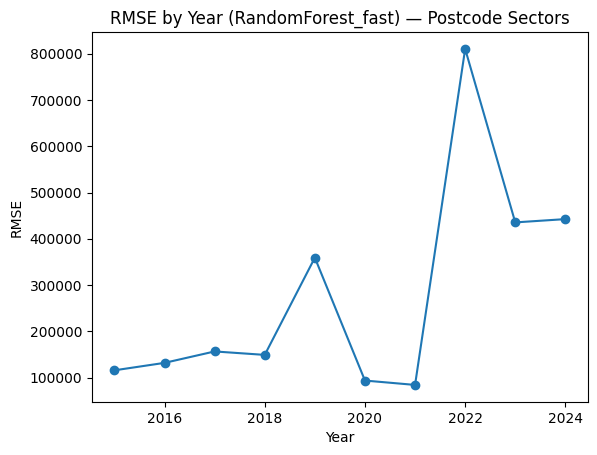

In [34]:
# ----------------------------
# 4f) Performance by year (best model)
# ----------------------------
pred_df = X_test.copy().reset_index(drop=True)
pred_df["actual"] = np.array(y_test)
pred_df["predicted"] = best_pred
pred_df["residual"] = pred_df["actual"] - pred_df["predicted"]

if "year" in pred_df.columns:
    year_perf = pred_df.groupby("year").apply(
        lambda d: pd.Series({
            "MAE": mean_absolute_error(d["actual"], d["predicted"]),
            "RMSE": np.sqrt(mean_squared_error(d["actual"], d["predicted"])),
            "R2": r2_score(d["actual"], d["predicted"]) if len(d) > 1 else np.nan,
            "N": len(d)
        })
    ).reset_index()

    print("\n=== Performance by year (best model) — Postcode Sectors ===")
    print(year_perf)

    plt.figure()
    plt.plot(year_perf["year"], year_perf["RMSE"], marker="o")
    plt.xlabel("Year")
    plt.ylabel("RMSE")
    plt.title(f"RMSE by Year ({best_model_name}) — Postcode Sectors")
    plt.show()

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['easting', 'northing', 'n_sales',
                                  'Female_Total', 'Male_Total',
                                  'Pop_Total_FM']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['year'])])
transformers_: [('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())]), ['easting', 'northing',

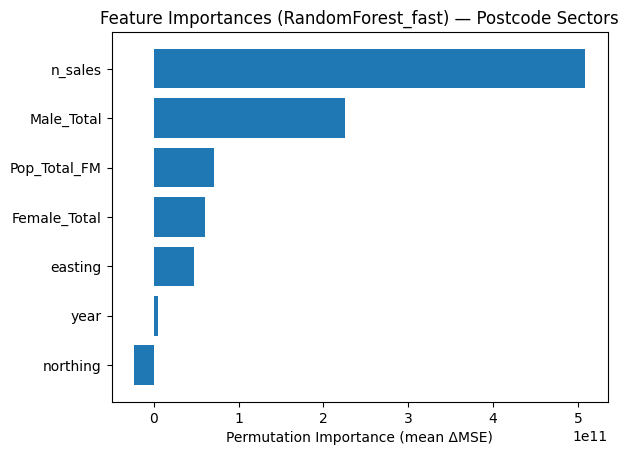

In [35]:
from sklearn.inspection import permutation_importance

# ----------------------------
# A) Permutation importance (sector model)
# ----------------------------
pre = best_pipe.named_steps["preprocess"]
print(pre)
print("transformers_:", getattr(pre, "transformers_", None))

perm = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_squared_error"
)

imp = perm.importances_mean
imp_std = perm.importances_std

# Use ORIGINAL feature columns: 6 numeric + year
feature_names_7 = np.array([
    "easting",
    "northing",
    "n_sales",
    "Female_Total",
    "Male_Total",
    "Pop_Total_FM",
    "year"
], dtype=str)

# If order differs, use X_test columns
if len(imp) == len(X_test.columns):
    feature_names = np.array(X_test.columns, dtype=str)
else:
    feature_names = feature_names_7[:len(imp)]

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": imp,
    "importance_std": imp_std
}).sort_values("importance_mean", ascending=False)

print("\n=== Permutation importance ===")
print(imp_df)

plt.figure()
plt.barh(imp_df["feature"][::-1], imp_df["importance_mean"][::-1])
plt.xlabel("Permutation Importance (mean ΔMSE)")
plt.title(f"Feature Importances ({best_model_name}) — Postcode Sectors")
plt.show()

In [37]:
# ============================================================
# FINAL PREDICTIONS + RANKINGS (postcode_sector × year)
# ============================================================

target_col = "avg_price"
df_model = final_df.copy()

# Build X used for prediction (same columns as training)
feature_cols = numeric_features + categorical_features
X_all = df_model[feature_cols].copy()

pred_col = f"pred_{best_model_name.lower()}"
resid_col = "residual"

df_model[pred_col] = best_pipe.predict(X_all)
df_model[resid_col] = df_model[target_col] - df_model[pred_col]

print("Predictions added:", pred_col)
print("df_model shape:", df_model.shape)

# ----------------------------
# Choose defensible minimum n_sales for ranking (sector)
# ----------------------------
candidates = [3, 5, 10, 15, 20, 25, 30]
min_rows_keep = max(200, int(0.60 * len(df_model)))  # sectors have fewer rows than units

keep_counts = []
for t in candidates:
    keep_n = (df_model["n_sales"] >= t).sum()
    keep_counts.append((t, keep_n))

print("\nRows kept by n_sales threshold:")
print(pd.DataFrame(keep_counts, columns=["threshold", "rows_kept"]))

chosen = None
for t, keep_n in reversed(keep_counts):
    if keep_n >= min_rows_keep:
        chosen = t
        break

if chosen is None:
    chosen = 5 if (df_model["n_sales"] >= 5).sum() > 0 else 3

MIN_TX_RANK = chosen
print("\n Chosen minimum n_sales for ranking:", MIN_TX_RANK)


Predictions added: pred_randomforest_fast
df_model shape: (1205, 15)

Rows kept by n_sales threshold:
   threshold  rows_kept
0          3       1194
1          5       1184
2         10       1133
3         15       1095
4         20       1052
5         25       1009
6         30        969

 Chosen minimum n_sales for ranking: 30


In [38]:
# ----------------------------
# Ranking dataset + optional trimming
# ----------------------------
df_rank = df_model[df_model["n_sales"] >= MIN_TX_RANK].copy()

LOW_Q, HIGH_Q = 0.01, 0.99
q_low = df_rank[target_col].quantile(LOW_Q)
q_high = df_rank[target_col].quantile(HIGH_Q)
df_rank = df_rank[(df_rank[target_col] >= q_low) & (df_rank[target_col] <= q_high)].copy()

print("\nRanking dataset shape (after filters):", df_rank.shape)

# ----------------------------
# Sector-level ranking across years (one row per postcode_sector)
# ----------------------------
sector_rank = (
    df_rank.groupby("postcode_sector", as_index=False)
      .agg(
          actual_mean=(target_col, "mean"),
          predicted_mean=(pred_col, "mean"),
          residual_mean=(resid_col, "mean"),
          total_sales=("n_sales", "sum"),
          years_covered=("year", "nunique")
      )
)

# Optional reliability: must appear in >= 3 years
sector_rank = sector_rank[sector_rank["years_covered"] >= 3].copy()

print("\nPostcode-sector ranking table:", sector_rank.shape)
print(sector_rank.head())



Ranking dataset shape (after filters): (950, 15)

Postcode-sector ranking table: (105, 6)
  postcode_sector    actual_mean  predicted_mean  residual_mean  total_sales  \
3           BS1 4  744869.471876   911498.565626 -166629.093750          243   
4           BS1 5  640667.335933   626907.740677   13759.595255          665   
5           BS1 6  886002.535293   753357.520980  132645.014313         1388   
6          BS10 5  311048.616667   355191.178415  -44142.561748          786   
7          BS10 6  271286.083442   332478.163552  -61192.080110         1422   

   years_covered  
3              4  
4              8  
5              7  
6              9  
7             10  


In [44]:
# Print top lists (sector)
# ----------------------------
# Recreate sector rankings
# ----------------------------
cols_show = [
    "postcode_sector",
    "actual_mean",
    "predicted_mean",
    "total_sales",
    "years_covered"
]

top_expensive = (
    sector_rank
    .sort_values("predicted_mean", ascending=False)
    .head(10)
)

top_affordable = (
    sector_rank
    .sort_values("predicted_mean", ascending=True)
    .head(10)
)

print("\nTOP 10 MOST EXPENSIVE POSTCODE SECTORS (PREDICTED)")
print(top_expensive[cols_show])

print("\nTOP 10 MOST AFFORDABLE POSTCODE SECTORS (PREDICTED)")
print(top_affordable[cols_show])


print("\nTOP 10 OVER-PREDICTED POSTCODE SECTORS (negative residuals)")
print(sector_rank.sort_values("residual_mean", ascending=True)[cols_show].head(10))

print("\nTOP 10 UNDER-PREDICTED POSTCODE SECTORS (positive residuals)")
print(sector_rank.sort_values("residual_mean", ascending=False)[cols_show].head(10))



TOP 10 MOST EXPENSIVE POSTCODE SECTORS (PREDICTED)
    postcode_sector    actual_mean  predicted_mean  total_sales  years_covered
52           BS32 4  925340.465742   965668.766925          394              6
3             BS1 4  744869.471876   911498.565626          243              4
63           BS35 4  586698.476798   765512.027727          433              6
5             BS1 6  886002.535293   753357.520980         1388              7
104           BS8 3  712690.182132   663627.067553         1012              9
4             BS1 5  640667.335933   626907.740677          665              8
106           BS9 1  655835.312412   624859.615941         1015              9
31            BS2 0  589498.987349   605334.117943          948              9
102           BS8 1  545131.760448   568516.201621          562              8
98            BS6 7  610791.275577   560526.740110         1195             10

TOP 10 MOST AFFORDABLE POSTCODE SECTORS (PREDICTED)
   postcode_sector    actu

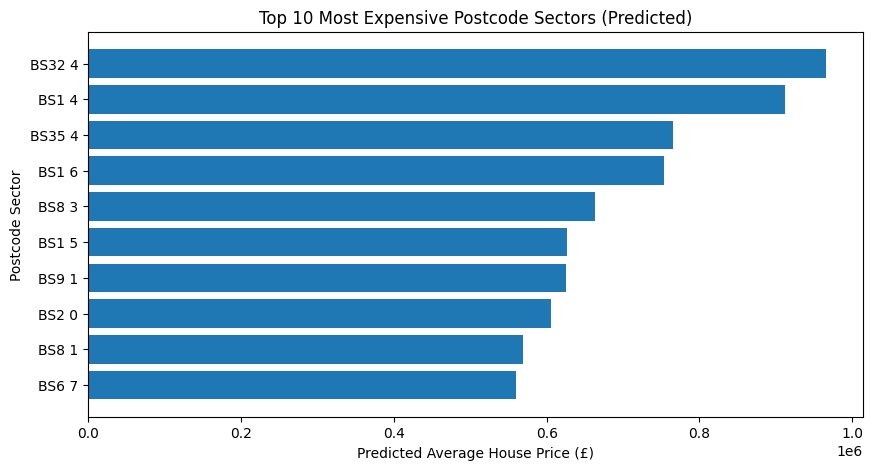

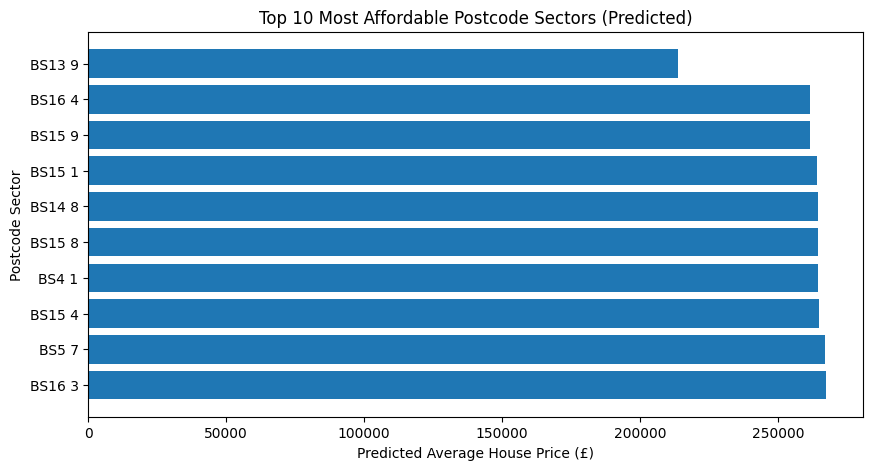

In [45]:
# Top 10 most expensive sectors

plt.figure(figsize=(10,5))

plt.barh(
    top_expensive["postcode_sector"][::-1],
    top_expensive["predicted_mean"][::-1]
)

plt.xlabel("Predicted Average House Price (£)")
plt.ylabel("Postcode Sector")
plt.title("Top 10 Most Expensive Postcode Sectors (Predicted)")
plt.show()


# Top 10 most affordable sectors

plt.figure(figsize=(10,5))

plt.barh(
    top_affordable["postcode_sector"][::-1],
    top_affordable["predicted_mean"][::-1]
)

plt.xlabel("Predicted Average House Price (£)")
plt.ylabel("Postcode Sector")
plt.title("Top 10 Most Affordable Postcode Sectors (Predicted)")
plt.show()


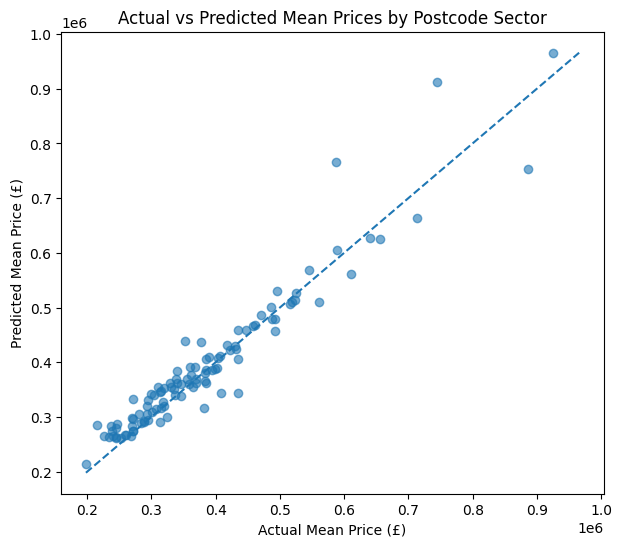

In [46]:
# Compare actual vs predicted (EDA diagnostic)
plt.figure(figsize=(7,6))

plt.scatter(
    sector_rank["actual_mean"],
    sector_rank["predicted_mean"],
    alpha=0.6
)

minv = min(sector_rank["actual_mean"].min(), sector_rank["predicted_mean"].min())
maxv = max(sector_rank["actual_mean"].max(), sector_rank["predicted_mean"].max())

plt.plot([minv, maxv], [minv, maxv], linestyle="--")

plt.xlabel("Actual Mean Price (£)")
plt.ylabel("Predicted Mean Price (£)")
plt.title("Actual vs Predicted Mean Prices by Postcode Sector")
plt.show()


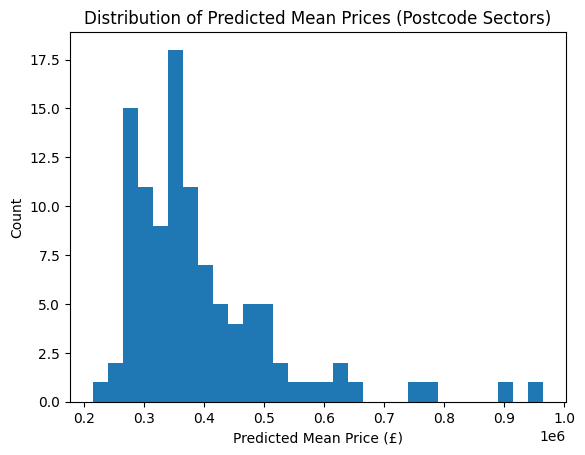

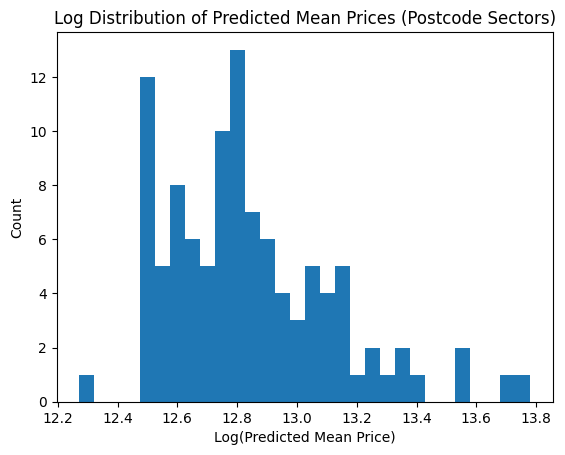

In [47]:
# Price spread across sectors (EDA distribution)

plt.figure()
sector_rank["predicted_mean"].plot(kind="hist", bins=30)
plt.xlabel("Predicted Mean Price (£)")
plt.ylabel("Count")
plt.title("Distribution of Predicted Mean Prices (Postcode Sectors)")
plt.show()

plt.figure()
np.log(sector_rank["predicted_mean"].clip(lower=1)).plot(kind="hist", bins=30)
plt.xlabel("Log(Predicted Mean Price)")
plt.ylabel("Count")
plt.title("Log Distribution of Predicted Mean Prices (Postcode Sectors)")
plt.show()


In [41]:
# ============================================================
# FINAL MAP OUTPUT — POSTCODE SECTORS (BS sectors)
# Assumes:
#   - final_df has postcode_sector, easting, northing, year, avg_price, median_price, n_sales
#   - best_pipe is fitted
#   - numeric_features + categorical_features defined
# ============================================================

# 1) Convert Easting/Northing → Latitude/Longitude
!pip -q install pyproj
from pyproj import Transformer
import numpy as np
import pandas as pd

transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

df_model = final_df.copy()

df_model["lon"], df_model["lat"] = transformer.transform(
    df_model["easting"].values,
    df_model["northing"].values
)

print("Lat/Lon created (sectors).")

# 2) Prepare data for clustering (clean lat/lon)
from sklearn.cluster import KMeans

df_cluster = df_model.copy()
df_cluster["lat"] = pd.to_numeric(df_cluster["lat"], errors="coerce")
df_cluster["lon"] = pd.to_numeric(df_cluster["lon"], errors="coerce")

df_cluster = df_cluster.replace([np.inf, -np.inf], np.nan)
df_cluster = df_cluster.dropna(subset=["lat", "lon"]).copy()

# Bristol bounds safety
df_cluster = df_cluster[
    df_cluster["lat"].between(51.0, 52.2) &
    df_cluster["lon"].between(-3.5, -2.0)
].copy()

print("Rows available for clustering:", df_cluster.shape[0])

coords = df_cluster[["lat", "lon"]].to_numpy(dtype=np.float64)

# 3) KMeans clustering
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(coords)

print("Clusters assigned.")
df_cluster[["postcode_sector", "lat", "lon", "cluster"]].head()

# 4) Ensure prediction column exists in df_cluster
import re

if "pred_col" not in globals():
    pred_col = f"pred_{best_model_name.lower()}"

# If no pred column exists, create predictions now (sector features)
if pred_col not in df_cluster.columns:
    pred_candidates = [c for c in df_cluster.columns if re.match(r"^pred_", str(c))]
    print("Available prediction columns:", pred_candidates)

    if not pred_candidates:
        print("No pred_* column found. Creating predictions now...")

        feature_cols = numeric_features + categorical_features
        X_map = df_cluster[feature_cols].copy()
        df_cluster[pred_col] = best_pipe.predict(X_map)

        print("Created:", pred_col)
    else:
        pred_col = pred_candidates[0]
        print("Using prediction column:", pred_col)

print("Using pred_col =", pred_col)
print("pred_col exists in df_cluster?", pred_col in df_cluster.columns)

Lat/Lon created (sectors).
Rows available for clustering: 1201
Clusters assigned.
Available prediction columns: []
No pred_* column found. Creating predictions now...
Created: pred_randomforest_fast
Using pred_col = pred_randomforest_fast
pred_col exists in df_cluster? True


In [42]:
# 5) Folium map (sector)
import folium
from folium.plugins import MarkerCluster

df_map = df_cluster.replace([np.inf, -np.inf], np.nan).dropna(subset=["lat", "lon", pred_col]).copy()

cluster_colors = [
    "red", "blue", "green", "purple", "orange",
    "pink", "cadetblue", "darkred", "darkblue"
]

m2 = folium.Map(
    location=[df_map["lat"].median(), df_map["lon"].median()],
    zoom_start=12,
    tiles="CartoDB positron",
    width="70%",
    height="500px"
)

mc = MarkerCluster().add_to(m2)

for _, r in df_map.iterrows():
    c = int(r.get("cluster", 0))
    col = cluster_colors[c % len(cluster_colors)]

    avg_price = r.get("avg_price", np.nan)
    med_price = r.get("median_price", np.nan)
    n_sales   = r.get("n_sales", 0)

    folium.CircleMarker(
        location=[float(r["lat"]), float(r["lon"])],
        radius=7,   # sectors are fewer points; slightly larger
        color=col,
        fill=True,
        fill_color=col,
        fill_opacity=0.65,
        popup=folium.Popup(
            f"""
            <b>{r.get('postcode_sector','')}</b><br>
            Cluster: {c}<br>
            Avg price: £{avg_price:,.0f}<br>
            Median price: £{med_price:,.0f}<br>
            Predicted: £{float(r[pred_col]):,.0f}<br>
            Sales: {int(n_sales)}
            """,
            max_width=280
        )
    ).add_to(mc)

m2